In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab  import files
uploaded= files.upload()

Saving cropYieldDataset.csv to cropYieldDataset.csv


In [ ]:
df= pd.read_csv("cropYieldDataset.csv")

In [ ]:
df.shape

(2192, 18)

In [ ]:
df.isnull().sum()

,0
system:index,0
cloud_coverage,1190
Date,0
day,0
mean_ndvi,1200
month,0
n_images,0
year,0
.geo,0
Region,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   system:index    2192 non-null   int64  
 1   cloud_coverage  1002 non-null   float64
 2   Date            2192 non-null   object 
 3   day             2192 non-null   int64  
 4   mean_ndvi       992 non-null    float64
 5   month           2192 non-null   int64  
 6   n_images        2192 non-null   int64  
 7   year            2192 non-null   int64  
 8   .geo            2192 non-null   object 
 9   Region          2192 non-null   object 
 10  Temp_Max        2192 non-null   float64
 11  Temp_Min        2192 non-null   float64
 12  Rain_mm         2192 non-null   float64
 13  Humidity        2192 non-null   int64  
 14  GWETPROF        2192 non-null   float64
 15  GWETROOT        2192 non-null   float64
dtypes: float64(7), int64(6), object(3)
memory usage: 274.1+ KB


In [ ]:
df.describe()

,system:index,cloud_coverage,day,mean_ndvi,month,n_images,year,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
count,2192.000000,1002.000000,2192.000000,992.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000
mean,182.166971,21.526148,15.732664,0.420656,6.521898,3.494069,2023.000912,29.810675,18.194571,1.858485,65.738595,0.428736,0.433777
std,105.486846,23.294116,8.803378,0.199744,3.449773,4.982302,0.816869,7.428135,7.579454,5.664703,19.343153,0.090854,0.102735
min,0.000000,0.000000,1.000000,-0.033874,1.000000,0.000000,2022.000000,12.400000,1.700000,0.000000,14.000000,0.330000,0.330000
25%,91.000000,0.676168,8.000000,0.233564,4.000000,0.000000,2022.000000,24.000000,11.375000,0.000000,57.000000,0.360000,0.360000
50%,182.000000,11.710482,16.000000,0.408744,7.000000,0.000000,2023.000000,31.600000,19.350000,0.000000,71.000000,0.400000,0.400000
75%,273.250000,39.022734,23.000000,0.610333,10.000000,6.000000,2024.000000,34.600000,25.200000,0.500000,80.000000,0.470000,0.480000
max,365.000000,79.538423,31.000000,0.791227,12.000000,28.000000,2024.000000,45.900000,33.900000,71.800000,94.000000,0.830000,0.910000


In [ ]:
df.head()

,system:index,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,.geo,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
0,0,NaN,01-01-22,1,NaN,1,0,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",Punjab,17.6,5.2,0.0,84,0.39,0.40
1,0,NaN,01-01-23,1,NaN,1,0,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",Punjab,17.0,6.3,0.0,86,0.39,0.40
2,0,NaN,01-01-24,1,NaN,1,0,2024,"{""type"":""MultiPoint"",""coordinates"":[]}",Punjab,15.4,5.9,0.0,91,0.44,0.45
3,31,17.372082,01-02-22,1,0.142464,2,8,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",Punjab,19.1,6.8,0.0,89,0.53,0.55
4,31,11.475587,01-02-23,1,0.700629,2,14,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",Punjab,18.4,6.8,0.0,83,0.41,0.42


In [ ]:
df=df.drop(["system:index",".geo"],axis=1)

In [ ]:
df.head(10)

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
0,NaN,01-01-22,1,NaN,1,0,2022,Punjab,17.6,5.2,0.0,84,0.39,0.40
1,NaN,01-01-23,1,NaN,1,0,2023,Punjab,17.0,6.3,0.0,86,0.39,0.40
2,NaN,01-01-24,1,NaN,1,0,2024,Punjab,15.4,5.9,0.0,91,0.44,0.45
3,17.372082,01-02-22,1,0.142464,2,8,2022,Punjab,19.1,6.8,0.0,89,0.53,0.55
4,11.475587,01-02-23,1,0.700629,2,14,2023,Punjab,18.4,6.8,0.0,83,0.41,0.42
5,23.557970,01-02-24,1,0.619677,2,5,2024,Punjab,16.8,9.1,15.6,90,0.43,0.44
6,0.036596,01-03-22,1,0.704035,3,2,2022,Punjab,22.8,10.3,3.6,73,0.49,0.51
7,60.593617,01-03-23,1,0.748373,3,2,2023,Punjab,26.0,13.7,2.6,72,0.37,0.37
8,NaN,01-03-24,1,NaN,3,0,2024,Punjab,22.0,13.5,1.7,71,0.41,0.42
9,NaN,01-04-22,1,NaN,4,0,2022,Punjab,34.7,17.4,0.0,35,0.38,0.38


### **Converting date column to datetime format**

In [ ]:
df['Date']= pd.to_datetime(df['Date'])

/tmp/ipython-input-2691600196.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']= pd.to_datetime(df['Date'])


In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
0,NaN,2022-01-01,1,NaN,1,0,2022,Punjab,17.6,5.2,0.0,84,0.39,0.40
1,NaN,2023-01-01,1,NaN,1,0,2023,Punjab,17.0,6.3,0.0,86,0.39,0.40
2,NaN,2024-01-01,1,NaN,1,0,2024,Punjab,15.4,5.9,0.0,91,0.44,0.45
3,17.372082,2022-01-02,1,0.142464,2,8,2022,Punjab,19.1,6.8,0.0,89,0.53,0.55
4,11.475587,2023-01-02,1,0.700629,2,14,2023,Punjab,18.4,6.8,0.0,83,0.41,0.42


# Reordering the datset by region and days

In [ ]:
df.sort_values(by=['Region','Date'], inplace=True)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
0,NaN,2022-01-01,1,NaN,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45
2,NaN,2022-01-03,1,NaN,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40
3,NaN,2022-01-04,1,NaN,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36
4,NaN,2022-01-05,1,NaN,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34


In [ ]:
df['mean_ndvi']=df['mean_ndvi'].interpolate(method='linear',limit_direction='both')
df.fillna({'cloud_coverage':0}, inplace=True)

In [ ]:
df.head()


,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,GWETPROF,GWETROOT
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34


# Creating column of **GROWING SEASON**

In [ ]:
def season(month):
  if month in [6,7,8,9,10]:
    return 'Kharif'
  elif month in [11,12,1,2,3,4]:
    return 'Rabi'
  else:
    return 'Off-season'
df['Season_Type']=df['month'].apply(season)

In [ ]:
df.head()
print(df['Season_Type'].value_counts())

Season_Type
Rabi          1088
Kharif         918
Off-season     186
Name: count, dtype: int64


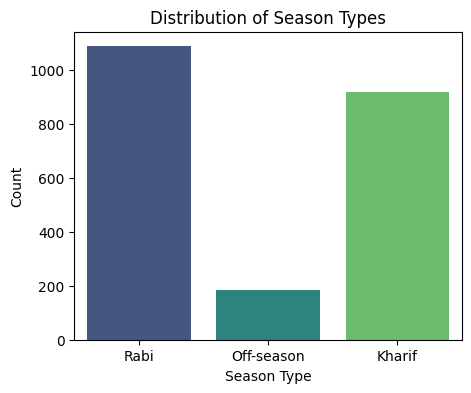

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Season_Type', data=df, palette='viridis', hue='Season_Type', legend=False)
plt.title('Distribution of Season Types')
plt.xlabel('Season Type')
plt.ylabel('Count')
plt.show()

In [ ]:
rename_map={'GWETPROF':'profile_soil_wetness',
            'GWETROOT':'root_zone_soil_wetness'}
df.rename(columns=rename_map, inplace=True)

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season


In [ ]:
numeric_columns= df.select_dtypes(include=['number'])

In [ ]:
cor_mat= numeric_columns.corr()

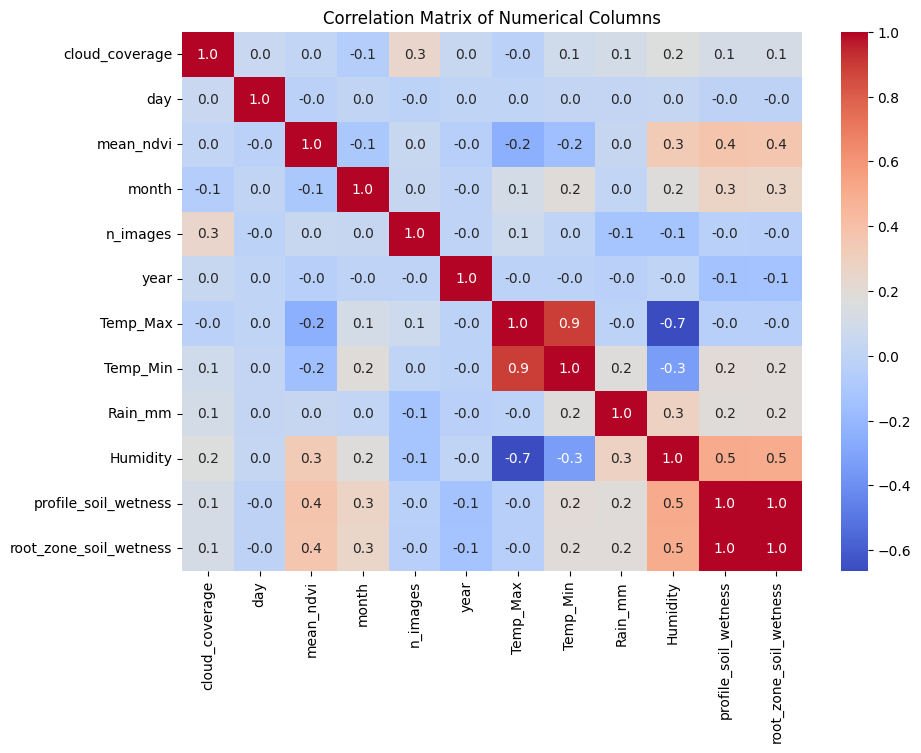

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cor_mat, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

# **Why is daily rainfall not correlated with nvdi?**
The heatmap is comparing today's rain to today's greenness and thus there is no direct corellation.
Thus we can add another feature of rainfall where we calculate the rain forpast 15 days.

Similarly, we need a column for heatwave as one day temperature doesnt affect the crops.

# **CREATING '14 DAYS RAIN', 'Heatwave', 'Coldwave' COLUMNS**

In [ ]:
df['14_dayRainSum'] = df['Rain_mm'].rolling(window=14).sum()


In [ ]:
hotThreshold= 40
heatwaveDuration=3
df['HotDay']=(df['Temp_Max']>hotThreshold).astype(int)
df['Heatwave']=(df['HotDay'].rolling(window=heatwaveDuration).sum()==heatwaveDuration).astype(int)

In [ ]:
coldThreshold=4
coldwaveDuration=2
df['ColdDay']=(df['Temp_Min']<=coldThreshold).astype(int)
df['Coldwave']=(df['ColdDay'].rolling(window=coldwaveDuration).sum()==coldwaveDuration).astype(int)

In [ ]:
df.drop(['HotDay','ColdDay'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
cloud_coverage,0
Date,0
day,0
mean_ndvi,0
month,0
n_images,0
year,0
Region,0
Temp_Max,0
Temp_Min,0


In [ ]:
df.fillna(0,inplace=True)

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0


In [ ]:
df["Coldwave"].value_counts()

,count
Coldwave,
0,2182
1,10


<Axes: >

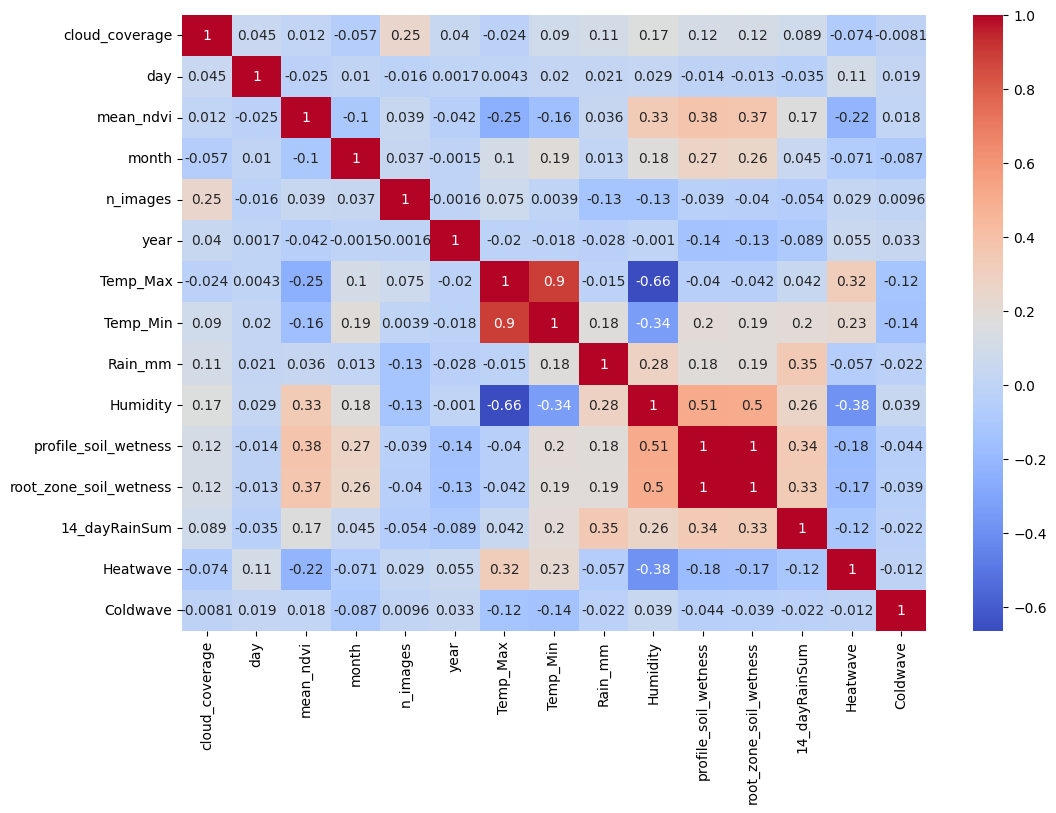

In [ ]:
numericdf2= df.select_dtypes(include=['number'])
plt.figure(figsize=(12,8))
sns.heatmap(numericdf2.corr(),annot=True,cmap='coolwarm')

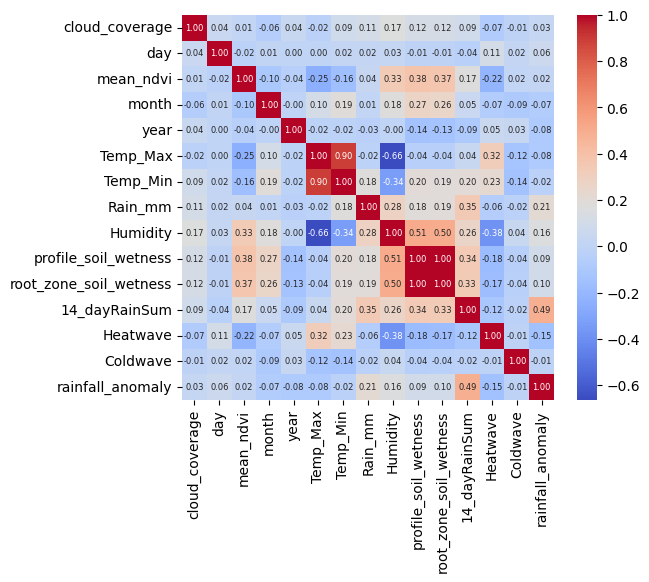

In [ ]:
numericdf3= df.select_dtypes(include=['number'])
plt.figure(figsize=(6,5))
sns.heatmap(numericdf3.corr(),annot=True,cmap='coolwarm', fmt='.2f', annot_kws={'size': 6})
plt.show()

# **STATIONARITY CHECK**

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
punjab_series = df[df['Region'] == 'Punjab']['mean_ndvi']
res_punjab = adfuller(punjab_series)
print('ADF Statistic:', res_punjab[0])
print('p-value:', res_punjab[1])
if res_punjab[1] <= 0.05:
    print("Stationary.")
else:
    print("Non-stationary.")

ADF Statistic: -7.24768073536816
p-value: 1.814190213428073e-10
Stationary.


In [ ]:
haryana_series= df[df['Region']=='Haryana']['mean_ndvi']
res_haryana= adfuller(haryana_series)
print('ADF Statistic:', res_haryana[0])
print('p-value: ',res_haryana[1])
if res_haryana[1]<=0.5:
  print("Stationary")
else:
  print("Non Stationary")

ADF Statistic: -6.086010226163652
p-value:  1.0640074458975845e-07
Stationary


In [ ]:
series= df['mean_ndvi']
res= adfuller(series)
print('ADF Statistic:', res[0])
print('p-value: ',res[1])
if res[1]<=0.5:
  print("Stationary")
else:
  print("Non Stationary")

ADF Statistic: -5.171885452263193
p-value:  1.0031576153680303e-05
Stationary


In [ ]:
df.head(

)

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0


In [ ]:
df['rain_30_day_sum'] = df.groupby('Region')['Rain_mm'].rolling(window=30).sum().reset_index(0,drop=True)


In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rain_30_day_sum
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0,NaN
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0,NaN
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0,NaN
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0,NaN
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0,NaN


In [ ]:
df['monthly_avg'] = df.groupby(['Region', df['Date'].dt.month])['rain_30_day_sum'].transform('mean')
df['monthly_std'] = df.groupby(['Region', df['Date'].dt.month])['rain_30_day_sum'].transform('std')

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,...,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rain_30_day_sum,monthly_avg,monthly_std
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,...,79,0.39,0.39,Rabi,0.0,0,0,NaN,31.417187,19.293716
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,...,86,0.45,0.45,Rabi,0.0,0,0,NaN,31.417187,19.293716
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,...,69,0.41,0.40,Rabi,0.0,0,0,NaN,31.417187,19.293716
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,...,27,0.36,0.36,Rabi,0.0,0,0,NaN,31.417187,19.293716
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,...,29,0.35,0.34,Off-season,0.0,0,0,NaN,31.417187,19.293716


In [ ]:
df['rainfall_anomaly'] = (df['rain_30_day_sum'] - df['monthly_avg']) / df['monthly_std']


In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,...,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rain_30_day_sum,monthly_avg,monthly_std,rainfall_anomaly
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,...,0.39,0.39,Rabi,0.0,0,0,NaN,31.417187,19.293716,NaN
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,...,0.45,0.45,Rabi,0.0,0,0,NaN,31.417187,19.293716,NaN
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,...,0.41,0.40,Rabi,0.0,0,0,NaN,31.417187,19.293716,NaN
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,...,0.36,0.36,Rabi,0.0,0,0,NaN,31.417187,19.293716,NaN
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,...,0.35,0.34,Off-season,0.0,0,0,NaN,31.417187,19.293716,NaN


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)
df = df.drop(columns=['monthly_avg', 'monthly_std', 'rain_30_day_sum'])


In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,n_images,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly
0,0.000000,2022-01-01,1,0.061829,1,0,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0,0.0
1,0.349554,2022-01-02,1,0.061829,2,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0,0.0
2,0.000000,2022-01-03,1,0.089505,3,0,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0,0.0
3,0.000000,2022-01-04,1,0.117181,4,0,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0,0.0
4,0.000000,2022-01-05,1,0.144858,5,0,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0,0.0


In [ ]:
df=df.drop(['n_images'],axis=1)

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly
0,0.000000,2022-01-01,1,0.061829,1,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0,0.0
1,0.349554,2022-01-02,1,0.061829,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0,0.0
2,0.000000,2022-01-03,1,0.089505,3,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0,0.0
3,0.000000,2022-01-04,1,0.117181,4,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0,0.0
4,0.000000,2022-01-05,1,0.144858,5,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0,0.0


In [ ]:
df.to_csv("FinalCropStressDataset.csv",index=False)
files.download("FinalCropStressDataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>